# Bukti minggu pertama — median harga laptop

Satu kategori, satu tahun anggaran. Tidak ada frontend, tidak ada API, tidak ada database.

**Kriteria lulus:**

1. Median laptop masuk akal saat dibaca mata — bukan angka yang jelas salah.
2. Share kategori `lain_lain` cukup kecil untuk kategori yang dituju.
3. Baris yang dibuang punya alasan yang bisa dijelaskan, dan jumlahnya wajar.
4. Outlier teratas benar-benar janggal saat dibaca manual, bukan artefak normalisasi.

Kalau salah satu gagal, berhenti di sini dan perbaiki aturan normalisasi.
Tidak ada stack yang bisa menyelamatkan benchmark yang salah.

## Sumber data

Notebook ini jatuh ke fixture kecil di `tests/fixtures/` supaya selalu bisa dijalankan dari clone bersih.
Fixture membuktikan pipeline-nya jalan. Fixture **tidak** membuktikan median apa pun — 28 baris yang ditulis
tangan untuk menguji aturan normalisasi hanya bisa memberi tahu bahwa aturannya berjalan, bukan bahwa
angkanya benar.

Untuk data sungguhan, arahkan ke folder CSV sendiri:

```
PELINTIR_SOURCE_DIR=/path/ke/csv uv run jupyter lab
```

Sebelum menaruh apa pun di folder itu:

- Sumbernya wajib punya baris di [`docs/data/legal-register.md`](../../../docs/data/legal-register.md).
  Status `unknown` dihitung sebagai dilarang.
- Data CC BY-NC-SA tidak boleh masuk ke apa pun yang diterbitkan —
  [ADR-0002](../../../docs/adr/0002-data-licence-lineage.md).
- Tidak ada scraper atau permintaan otomatis ke `katalog.inaproc.id` / `data.inaproc.id` sampai
  [ADR-0006](../../../docs/adr/0006-scrape-ekatalog-storefront.md) berstatus Accepted. Unduh manual dulu.

Folder `data/` sudah di-gitignore. Jangan pernah commit CSV, Parquet, atau DuckDB.


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from pipeline import benchmark as bench
from pipeline import normalize
from pipeline.sources import LocalCsvSource
from pipeline.sources.base import to_frame

pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(60)

FISCAL_YEAR = 2023
CATEGORY = "laptop"

# Ganti ke folder CSV asli yang kamu unduh. Kalau belum ada, notebook jatuh ke
# fixture kecil di tests/ supaya tetap bisa dijalankan dari awal.
PACKAGE_ROOT = Path.cwd().parent
SOURCE_DIR = Path(os.environ.get("PELINTIR_SOURCE_DIR", PACKAGE_ROOT / "tests" / "fixtures"))

print(f"sumber: {SOURCE_DIR}")

sumber: /home/syaddad/github_repo/pelintir/packages/pipeline/tests/fixtures


## 1. Ambil data mentah

Tidak ada transformasi di sini. Apa adanya dari sumber.

In [2]:
source = LocalCsvSource(SOURCE_DIR)
raw_items = to_frame(source.fetch(FISCAL_YEAR))

print(f"{len(raw_items)} baris mentah")
raw_items.head(5)

28 baris mentah


source,source_id,fiscal_year,agency_name,vendor_name,package_title,line_no,item_description,unit,quantity,unit_price,total_price,source_url
str,str,i16,str,str,str,i32,str,str,f64,f64,f64,str
"""local_csv""","""PKT-2023-001""",2023,"""Dinas Pendidikan Kota Bandung""","""PT. Anu Jaya""","""Pengadaan Laptop Guru""",1,"""Laptop Lenovo ThinkPad E14 i5 8GB 512GB SSD""","""unit""",10.0,1.25e7,1.25e8,null
"""local_csv""","""PKT-2023-001""",2023,"""Dinas Pendidikan Kota Bandung""","""PT. Anu Jaya""","""Pengadaan Laptop Guru""",2,"""Tas Laptop 14 inch""","""bh""",10.0,150000.0,1.5e6,null
"""local_csv""","""PKT-2023-002""",2023,"""Dinas Pendidikan Kota Bandung""","""PT ANU JAYA""","""Pengadaan Laptop Lab Komputer""",1,"""Laptop ASUS VivoBook A416 i3 8GB 256GB""","""Unit""",20.0,7.8e6,1.56e8,null
"""local_csv""","""PKT-2023-003""",2023,"""Sekretariat Daerah Kabupaten Bogor""","""CV Sinar Terang""","""Belanja Modal Peralatan Kantor""",1,"""Laptop Acer Aspire 5 Ryzen 5 8GB 512GB""","""UNIT""",5.0,9.2e6,4.6e7,null
"""local_csv""","""PKT-2023-004""",2023,"""Sekretariat Daerah Kabupaten Bogor""","""CV. Sinar Terang""","""Belanja Modal Peralatan Kantor""",1,"""LAPTOP HP PROBOOK 440 G9 I5 16GB""","""unt""",4.0,1.54e7,6.16e7,null


## 2. Normalisasi

Baris tidak dihapus, hanya diberi label. Yang dibuang harus bisa dijelaskan.

In [3]:
normalized = normalize.normalize(raw_items)
usable, rejected = normalize.split_usable(normalized)

print(f"terpakai: {len(usable)}   dibuang: {len(rejected)}")
rejected["reject_reason"].value_counts(sort=True)

terpakai: 26   dibuang: 2


reject_reason,count
str,u32
"""kuantitas tidak valid""",1
"""deskripsi kosong""",1


### Cakupan kategori

Share `lain_lain` adalah ukuran jujur seberapa jauh aturan normalisasi menjangkau.
Angka tinggi bukan bencana — asal kategori yang kamu benchmark bukan bagian dari sisanya.

In [4]:
coverage = (
    usable.group_by("canonical_category")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / pl.col("n").sum() * 100).round(1).alias("persen"))
    .sort("n", descending=True)
)
coverage

canonical_category,n,persen
str,u32,f64
"""laptop""",13,50.0
"""kursi_kerja""",6,23.1
"""printer""",3,11.5
"""alat_tulis""",2,7.7
"""aksesori_it""",1,3.8
"""meja_kerja""",1,3.8


In [5]:
# Baca 20 baris lain_lain. Kalau ada laptop nyasar di sini, aturannya kurang.
usable.filter(pl.col("canonical_category") == "lain_lain").select(
    "item_description", "canonical_unit", "unit_price"
).head(20)

item_description,canonical_unit,unit_price
str,str,f64


## 3. Benchmark

SQL-nya ada di `sql/benchmark.sql`, di-versioning git. Grup dengan `n` di bawah
ambang tidak diterbitkan — median dari tiga baris itu anekdot, bukan benchmark.

In [6]:
benchmarks = bench.run(usable, min_group_size=5)
benchmarks.select(
    "canonical_category",
    "canonical_unit",
    "n",
    "min_price",
    "p25",
    "median_price",
    "p75",
    "max_price",
)

canonical_category,canonical_unit,n,min_price,p25,median_price,p75,max_price
str,str,i64,f64,f64,f64,f64,f64
"""laptop""","""unit""",13,6.7e6,9.2e6,1.25e7,1.89e7,1.87e8
"""kursi_kerja""","""buah""",6,620000.0,753750.0,815000.0,2.6125e6,9.8e6


In [7]:
target = benchmarks.filter(pl.col("canonical_category") == CATEGORY)

if len(target) == 0:
    raise SystemExit(f"Kategori {CATEGORY!r} tidak lolos ambang n. Perluas data atau aturan.")

row = target.row(0, named=True)
print(f"n           : {row['n']}")
print(f"median      : Rp {row['median_price']:,.0f}")
print(f"p25 - p75   : Rp {row['p25']:,.0f} - Rp {row['p75']:,.0f}")
print(f"min - max   : Rp {row['min_price']:,.0f} - Rp {row['max_price']:,.0f}")
print()
print("Pertanyaannya sederhana: kamu percaya median ini?")

n           : 13
median      : Rp 12,500,000
p25 - p75   : Rp 9,200,000 - Rp 18,900,000
min - max   : Rp 6,700,000 - Rp 187,000,000

Pertanyaannya sederhana: kamu percaya median ini?


## 4. Distribusi

Skala log: harga pengadaan condong berat ke kanan, dan skala linear membuat
seluruh distribusi menempel di satu batang.

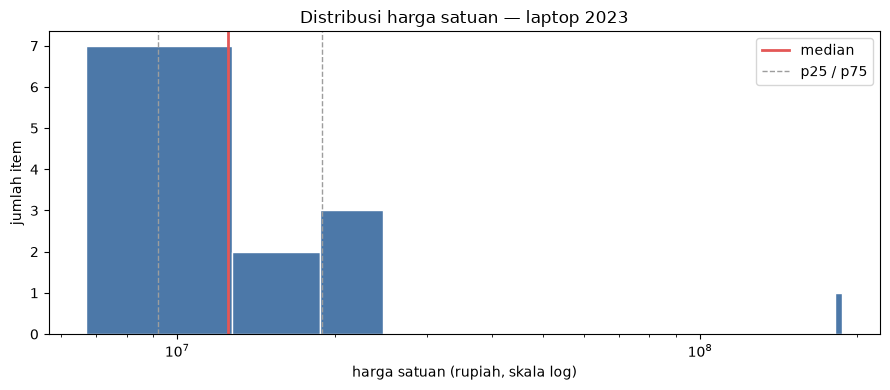

In [8]:
prices = usable.filter(pl.col("canonical_category") == CATEGORY)["unit_price"].to_list()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(prices, bins=30, color="#4c78a8", edgecolor="white")
ax.axvline(row["median_price"], color="#e45756", linewidth=2, label="median")
ax.axvline(row["p25"], color="#9d9d9d", linestyle="--", linewidth=1, label="p25 / p75")
ax.axvline(row["p75"], color="#9d9d9d", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("harga satuan (rupiah, skala log)")
ax.set_ylabel("jumlah item")
ax.set_title(f"Distribusi harga satuan — {CATEGORY} {FISCAL_YEAR}")
ax.legend()
plt.tight_layout()

## 5. Outlier

Pakai MAD, bukan standar deviasi: satu baris 100x akan menggelembungkan stddev
sampai outlier lain ikut tersembunyi di belakangnya.

**Baca 20 baris ini satu per satu.** Kalau yang muncul cuma kesalahan satuan atau
kategori nyasar, itu bug normalisasi, bukan temuan.

In [9]:
flagged = bench.outliers(usable, benchmarks, threshold=3.0)

flagged.select(
    "item_description",
    "canonical_category",
    "canonical_unit",
    "quantity",
    "unit_price",
    "median_price",
    pl.col("price_ratio").round(1).alias("x_median"),
    "agency_name",
    "vendor_name",
).head(20)

item_description,canonical_category,canonical_unit,quantity,unit_price,median_price,x_median,agency_name,vendor_name
str,str,str,f64,f64,f64,f64,str,str
"""Kursi Kerja Ergonomis Impor""","""kursi_kerja""","""buah""",10.0,9.8e6,815000.0,12.0,"""Badan Kepegawaian Daerah Kota Surabaya""","""CV Karya Utama"""
"""Laptop Premium Spesifikasi Khusus Auditor""","""laptop""","""unit""",2.0,1.87e8,1.25e7,15.0,"""Inspektorat Kabupaten Sleman""","""CV Karya Utama"""
"""Kursi Kerja Direktur Kulit Sandaran Tinggi""","""kursi_kerja""","""buah""",4.0,3.2e6,815000.0,3.9,"""Dinas Sosial Kota Malang""","""PT Anu Jaya Abadi"""


## Putusan

Dijalankan pada `tests/fixtures/sample_items.csv` — 28 baris tahun 2023, 2026-08-08.

- **Median masuk akal?** Ya untuk dibaca mata. Rp 12.500.000 per unit adalah harga laptop kantor 2023 yang
  wajar, dan rentang p25–p75 Rp 9,2 juta – Rp 18,9 juta menutupi kelas Celeron sampai i7. Ekor atas menarik
  p75 ke atas; median tidak bergerak, yang memang alasan memakai median.
- **Share `lain_lain`?** 0% dari 26 baris terpakai; enam kategori terisi semua. `Tas Laptop 14 inch` mendarat
  di `aksesori_it`, bukan `laptop` — urutan `CATEGORY_RULES` yang menaruh `aksesori_it` lebih dulu memang
  bekerja, dan itu satu-satunya hal yang menjaga median laptop dari tercemar harga tas.
- **Baris terbuang wajar?** 2 dari 28, dua-duanya punya nama: `kuantitas tidak valid` (1),
  `deskripsi kosong` (1). Tidak ada yang dibuang diam-diam.
- **Outlier teratas janggal?** 3 baris lolos ambang 3,0 MAD. Teratas `Kursi Kerja Ergonomis Impor` 12× median
  kelompoknya, lalu `Laptop Premium Spesifikasi Khusus Auditor` 15× median. Bukan salah satuan, bukan kategori
  nyasar — dua-duanya deskripsi kabur yang memang pantas ditanya. Persis bentuk yang dicari.

### Tapi ini belum bukti

Keempat kriteria lulus, dan itu hanya berarti **pipeline-nya utuh**: ingest, normalisasi, pengelompokan,
median, dan deteksi ekor atas berjalan dari ujung ke ujung tanpa pecah.

Fixture ini ditulis untuk menguji aturan yang ada. `lain_lain` 0% adalah cerminan fixture, bukan cakupan aturan
di dunia nyata — data sungguhan akan penuh singkatan, salah ketik, dan barang yang tidak masuk 16 aturan mana
pun. Median atas 13 baris buatan adalah fixture, bukan benchmark; ambang `min_peer_n` sendiri ada karena median
atas segelintir baris itu anekdot.

**Belum boleh lanjut ke frontend.** Yang dibutuhkan berikutnya adalah satu kategori nyata dari CSV nyata, lalu
notebook ini dijalankan ulang dan keempat pertanyaan di atas dijawab lagi. Itu terhalang akses data
([ADR-0006](../../../docs/adr/0006-scrape-ekatalog-storefront.md)), bukan terhalang kode.

Kalau nanti ada kriteria yang gagal — perbaiki aturan di `src/pipeline/normalize.py`, tambah test-nya, ulangi.
